<a href="https://colab.research.google.com/github/SabrinaZ600/AI-four-dimension-project/blob/main/06_AI_Visibility_Results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ==========================================================
# Import Libraries
# ==========================================================

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "figure.dpi": 120
})

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

import statsmodels.api as sm

In [5]:
# ==========================================================
# Project Directory
# ==========================================================

PROJECT_DIR = "/content/drive/MyDrive/AI_Brand_Project"

DATA_DIR = os.path.join(PROJECT_DIR, "data")

OUTPUT_DIR = os.path.join(PROJECT_DIR, "output")

# ==========================================================
# Figure Directory
# ==========================================================

FIGURE_DIR = os.path.join(PROJECT_DIR, "figures")
os.makedirs(FIGURE_DIR, exist_ok=True)

In [25]:
import shutil

if os.path.exists("/content/drive"):
    shutil.rmtree("/content/drive")

In [26]:
from google.colab import drive

drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [6]:
ranking_df = pd.read_csv(
    os.path.join(
        OUTPUT_DIR,
        "brand_rankings.csv"
    )
)

ranking_df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/AI_Brand_Project/output/brand_rankings.csv'

In [23]:
# ==========================================================
# Create Brand Metrics Dataset
# ==========================================================

brand_metrics = pd.DataFrame({

    "Brand":[
        "Sony",
        "Bose",
        "Sennheiser",
        "SoundCore",
        "JBL",
        "Nothing",
        "Edifier"
    ],

    "Total_Posts":[
        39105,
        33814,
        10389,
        6416,
        12203,
        4408,
        28977
    ],

    "Positive_Proportion":[
        0.17,
        0.24,
        0.07,
        0.30,
        0.22,
        0.09,
        0.12
    ],

    "Trust_Score":[
        4.434,
        4.674,
        4.240,
        4.405,
        4.394,
        4.150,
        4.230
    ],

    "Product_Strength":[
        4.14,
        4.17,
        4.25,
        4.17,
        4.22,
        3.62,
        4.23
    ],

    "Marketing_Strength":[
        0.64553685,
        0.92886686,
        0.06033231,
        0.48841749,
        0.62340474,
        0.36723699,
        0.46449625
    ]

})

brand_metrics

,Brand,Total_Posts,Positive_Proportion,Trust_Score,Product_Strength,Marketing_Strength
0,Sony,39105,0.17,4.434,4.14,0.645537
1,Bose,33814,0.24,4.674,4.17,0.928867
2,Sennheiser,10389,0.07,4.240,4.25,0.060332
3,SoundCore,6416,0.30,4.405,4.17,0.488417
4,JBL,12203,0.22,4.394,4.22,0.623405
5,Nothing,4408,0.09,4.150,3.62,0.367237
6,Edifier,28977,0.12,4.230,4.23,0.464496


In [24]:
# ==========================================================
# Save Brand Metrics
# ==========================================================

brand_metrics_file = os.path.join(
    DATA_DIR,
    "brand_metrics.csv"
)

brand_metrics.to_csv(
    brand_metrics_file,
    index=False
)

print("Saved to:")
print(brand_metrics_file)

OSError: Cannot save file into a non-existent directory: '/content/drive/MyDrive/AI_Brand_Project/data'

In [9]:
# ==========================================================
# Load Brand Metrics
# ==========================================================

brand_df = pd.read_csv(
    brand_metrics_file
)

brand_df

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/AI_Brand_Project/data/brand_metrics.csv'

In [10]:
# ==========================================================
# Merge AI Visibility with Brand Metrics
# ==========================================================

analysis_df = ranking_df.merge(
    brand_df,
    on="Brand",
    how="left"
)

analysis_df.head(10)

NameError: name 'ranking_df' is not defined

In [ ]:
print("Rows:", len(analysis_df))

print("\nMissing values:")

analysis_df.isna().sum()

In [ ]:
analysis_file = os.path.join(
    OUTPUT_DIR,
    "analysis_dataset.csv"
)

analysis_df.to_csv(
    analysis_file,
    index=False
)

print("Saved!")

In [ ]:
#Section 3 — Exploratory Data Analysis (EDA)
analysis_df.info()

In [ ]:
mention_summary = (
    analysis_df
    .groupby("Brand")["Mention"]
    .sum()
    .sort_values(ascending=False)
)

mention_summary

In [ ]:
rank_summary = (
    analysis_df
    .groupby("Brand")["Rank"]
    .mean()
    .sort_values()
)

rank_summary

In [ ]:
#Section 4 — Correlation Analysis
brand_analysis = (
    analysis_df
    .groupby("Brand")
    .agg(
        Mention_Rate=("Mention","mean"),
        Average_Rank=("Rank","mean"),
        Total_Posts=("Total_Posts","first"),
        Positive_Proportion=("Positive_Proportion","first"),
        Trust_Score=("Trust_Score","first"),
        Product_Strength=("Product_Strength","first"),
        Marketing_Strength=("Marketing_Strength","first")
    )
)

brand_analysis

In [ ]:
corr = brand_analysis.corr(
    numeric_only=True
)

corr.round(3)

In [ ]:
corr.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "correlation_matrix.csv"
    )
)

In [11]:
# Section 5 Logistic Regression
# ==========================================================
# Logistic Regression
# ==========================================================

model_df = analysis_df.copy()

features = [
    "Total_Posts",
    "Positive_Proportion",
    "Trust_Score",
    "Product_Strength",
    "Marketing_Strength"
]

X = model_df[features]

y = model_df["Mention"]

NameError: name 'analysis_df' is not defined

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [12]:
import statsmodels.api as sm

X_sm = sm.add_constant(X_scaled)

logit_model = sm.Logit(y, X_sm)

result = logit_model.fit()

print(result.summary())

NameError: name 'X_scaled' is not defined

In [13]:
# Section 6 AI Blind Spot
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

brand_strength = brand_df.copy()

cols = [
    "Total_Posts",
    "Positive_Proportion",
    "Trust_Score"
]

brand_strength[cols] = scaler.fit_transform(
    brand_strength[cols]
)

brand_strength["Brand_Strength"] = (
    brand_strength[cols].mean(axis=1)
)

NameError: name 'brand_df' is not defined

In [14]:
brand_strength["Reality_Rank"] = (
    brand_strength["Brand_Strength"]
    .rank(ascending=False)
)

visibility = pd.read_csv(
    os.path.join(
        OUTPUT_DIR,
        "AI_Visibility_Score.csv"
    )
)

visibility["AI_Rank"] = (
    visibility["AI_Visibility"]
    .rank(ascending=False)
)

NameError: name 'brand_strength' is not defined

In [15]:
comparison = (
    brand_strength[
        ["Brand", "Reality_Rank"]
    ]
    .merge(
        visibility[
            ["Brand", "AI_Rank", "AI_Visibility"]
        ],
        on="Brand"
    )
)

comparison["Gap"] = (
    comparison["Reality_Rank"]
    - comparison["AI_Rank"]
)

comparison

NameError: name 'brand_strength' is not defined

In [16]:
def classify_gap(gap):

    if gap >= 2:

        return "AI Over-recommended"

    elif gap <= -2:

        return "AI Under-recommended"

    else:

        return "Aligned"

comparison["Classification"]=comparison["Gap"].apply(classify_gap)

comparison

NameError: name 'comparison' is not defined

In [ ]:
# Section 7 Prompt-Level AI Recommendation Heatmap
# ==========================================================
# Prompt × Brand Mention Matrix
# ==========================================================

mention_matrix = (
    analysis_df
    .pivot_table(
        index="Prompt_ID",
        columns="Brand",
        values="Mention",
        fill_value=0
    )
)

mention_matrix

In [17]:
# ==========================================================
# Mention Heatmap
# ==========================================================

plt.figure(figsize=(10,8))

plt.imshow(
    mention_matrix,
    aspect="auto"
)

plt.colorbar(label="Mention")

plt.xticks(
    range(len(mention_matrix.columns)),
    mention_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(mention_matrix.index)),
    mention_matrix.index
)

plt.xlabel("Brand")

plt.ylabel("Prompt")

plt.title("AI Recommendation Heatmap")

plt.tight_layout()

plt.show()

NameError: name 'mention_matrix' is not defined

<Figure size 1200x960 with 0 Axes>

In [18]:
rank_matrix = (
    analysis_df
    .pivot_table(
        index="Prompt_ID",
        columns="Brand",
        values="Rank"
    )
)

rank_matrix

NameError: name 'analysis_df' is not defined

In [ ]:
plt.figure(figsize=(10,8))

plt.imshow(
    rank_matrix,
    aspect="auto"
)

plt.colorbar(label="Average Rank")

plt.xticks(
    range(len(rank_matrix.columns)),
    rank_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(rank_matrix.index)),
    rank_matrix.index
)

plt.xlabel("Brand")

plt.ylabel("Prompt")

plt.title("AI Ranking Heatmap")

plt.tight_layout()

plt.show()

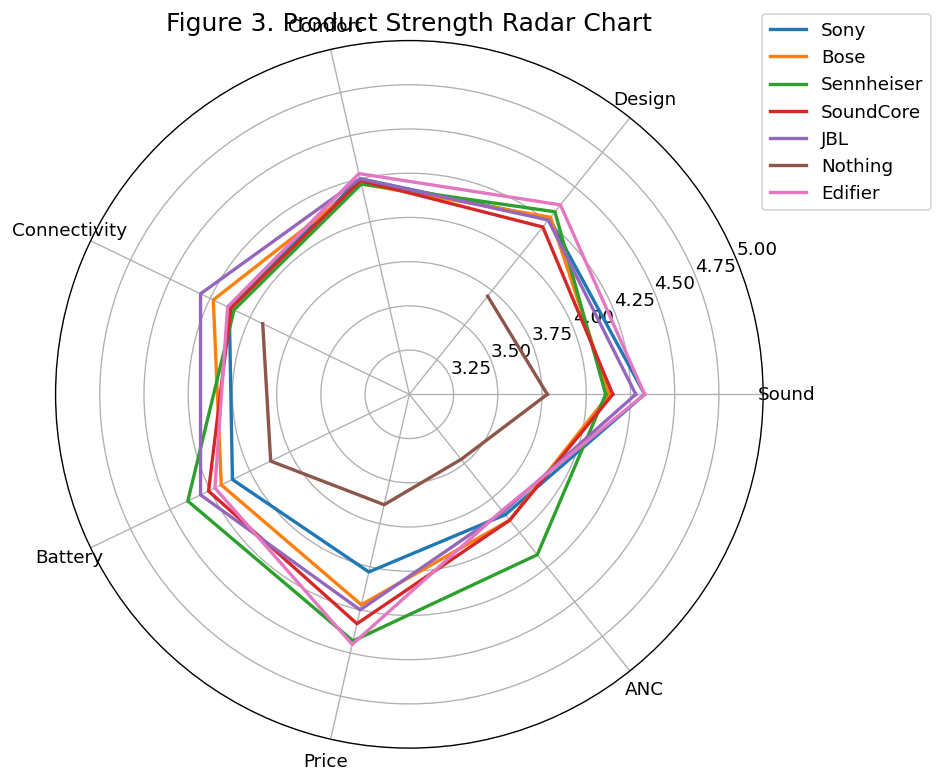

In [19]:
# ==========================================================
# Additional Plots
# Figure 1 Product Strength Radar Chart
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np

categories = [
    "Sound",
    "Design",
    "Comfort",
    "Connectivity",
    "Battery",
    "Price",
    "ANC"
]

product_scores = {

    "Sony":[4.33,4.27,4.25,4.13,4.11,4.03,3.87],
    "Bose":[4.13,4.28,4.22,4.23,4.18,4.22,3.91],
    "Sennheiser":[4.11,4.32,4.22,4.10,4.39,4.43,4.16],
    "SoundCore":[4.15,4.21,4.24,4.12,4.26,4.33,3.91],
    "JBL":[4.28,4.26,4.25,4.31,4.31,4.25,3.85],
    "Nothing":[3.78,3.71,2.98,3.92,3.87,3.64,3.47],
    "Edifier":[4.33,4.37,4.28,4.14,4.22,4.45,3.84]

}

angles = np.linspace(
    0,
    2*np.pi,
    len(categories),
    endpoint=False
).tolist()

angles += angles[:1]

fig = plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)

for brand, values in product_scores.items():

    values = values + values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=brand
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)

ax.set_ylim(3,5)

plt.legend(
    bbox_to_anchor=(1.25,1.05)
)

plt.title(
    "Figure 3. Product Strength Radar Chart",
    fontsize= 15
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "Figure3_ProductStrengthRadar.png"
    ),
    dpi=300
)

plt.show()

In [20]:
# ==========================================================
# Figure 2 Marketing Strength
# ==========================================================

import matplotlib.pyplot as plt

marketing = brand_df.sort_values(
    "Marketing_Strength",
    ascending=False
)

plt.figure(figsize=(8,5))

plt.bar(
    marketing["Brand"],
    marketing["Marketing_Strength"]
)

plt.ylabel("Marketing Strength")

plt.xlabel("Brand")

plt.title(
    "Figure 4. Marketing Strength Across Brands"
)

plt.box(False)

plt.tight_layout()

plt.savefig(

os.path.join(
FIGURE_DIR,
"Figure4_MarketingStrength.png"
),

dpi=300

)

plt.show()

NameError: name 'brand_df' is not defined

In [ ]:
# ==========================================================
# Figure 3 AI Visibility
# ==========================================================

visibility = visibility.sort_values(
    "AI_Visibility",
    ascending=False
)

plt.figure(figsize=(8,5))

plt.bar(
    visibility["Brand"],
    visibility["AI_Visibility"]
)

plt.ylabel("AI Visibility")

plt.xlabel("Brand")

plt.title(
    "Figure 5. AI Visibility Index"
)

plt.box(False)

plt.tight_layout()

plt.savefig(

os.path.join(
FIGURE_DIR,
"Figure5_AIVisibility.png"
),

dpi=300

)

plt.show()

In [21]:
# ==========================================================
# Figure 4 Correlation Heatmap
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np

corr_plot = corr.round(2)

fig, ax = plt.subplots(
    figsize=(8,6)
)

im = ax.imshow(
    corr_plot,
    cmap="Blues",
    vmin=-1,
    vmax=1
)

ax.set_xticks(
    np.arange(len(corr_plot.columns))
)

ax.set_xticklabels(
    corr_plot.columns,
    rotation=45,
    ha="right"
)

ax.set_yticks(
    np.arange(len(corr_plot.index))
)

ax.set_yticklabels(
    corr_plot.index
)

for i in range(len(corr_plot.index)):
    for j in range(len(corr_plot.columns)):
        ax.text(
            j,
            i,
            corr_plot.iloc[i,j],
            ha="center",
            va="center",
            fontsize=9
        )

plt.colorbar(im)

plt.title(
    "Correlation Matrix"
)

plt.tight_layout()

plt.savefig(

os.path.join(
FIGURE_DIR,
"Figure6_CorrelationHeatmap.png"
),

dpi=300

)

plt.show()

NameError: name 'corr' is not defined

In [ ]:
# ==========================================================
# Figure 5 Brand Strength vs AI Visibility
# ==========================================================

plt.figure(figsize=(8,6))

plt.scatter(
    comparison["Reality_Rank"],
    comparison["AI_Visibility"],
    s=140
)

for _, row in comparison.iterrows():

    plt.text(
        row["Reality_Rank"]+0.05,
        row["AI_Visibility"]+1,
        row["Brand"],
        fontsize=10
    )

plt.gca().invert_xaxis()

plt.xlabel("Reality Brand Rank\n(1 = Strongest Brand)")
plt.ylabel("AI Visibility Score")

plt.title(
    "Figure 4. Brand Strength versus AI Visibility",
    fontsize=14,
    fontweight="bold"
)

plt.grid(alpha=.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "Figure4_BrandStrength_vs_AIVisibility.png"
    ),
    dpi=300
)

plt.show()

In [ ]:
# ==========================================================
# Figure 6 AI Blind Spot Diagnosis
# ==========================================================

import numpy as np

comparison_plot = comparison.copy()

comparison_plot["Brand_Strength"] = 8 - comparison_plot["Reality_Rank"]

x = comparison_plot["Brand_Strength"]
y = comparison_plot["AI_Visibility"]

plt.figure(figsize=(8,6))

plt.scatter(
    x,
    y,
    s=180
)

for _, row in comparison_plot.iterrows():

    plt.text(
        row["Brand_Strength"]+0.05,
        row["AI_Visibility"]+1,
        row["Brand"],
        fontsize=10
    )

plt.axvline(
    np.mean(x),
    linestyle="--"
)

plt.axhline(
    np.mean(y),
    linestyle="--"
)

plt.text(
    np.mean(x)+0.2,
    max(y)-5,
    "High Brand\nHigh AI",
    fontsize=10
)

plt.text(
    min(x),
    max(y)-5,
    "AI Over-\nrecommended",
    fontsize=10
)

plt.text(
    np.mean(x)+ 2.2,
    min(y)+ 2,
    "AI Under-\nrecommended",
    fontsize=10
)

plt.text(
    min(x),
    min(y)+5,
    "Low Brand\nLow AI",
    fontsize=10
)

plt.xlabel("Brand Strength")

plt.ylabel("AI Visibility")

plt.title(
    "AI Brand Visibility Blind Spot",
    fontsize=14,
    fontweight="bold"
)

plt.grid(alpha=.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "Figure5_AIBlindSpot.png"
    ),
    dpi=300
)

plt.show()

In [ ]:
# ==========================================================
# Figure 7 Logistic Regression Coefficients
# ==========================================================

coef_df = pd.DataFrame({

    "Variable":[
        "Marketing Strength",
        "Product Strength",
        "Positive Proportion",
        "Total Posts",
        "Trust Score"
    ],

    "Coefficient":[
        result.params[5],
        result.params[4],
        result.params[2],
        result.params[1],
        result.params[3]
    ]

})

fig, ax = plt.subplots(figsize=(8,5))

y = np.arange(len(coef_df))

ax.hlines(
    y=y,
    xmin=0,
    xmax=coef_df["Coefficient"],
    linewidth=3
)

ax.scatter(
    coef_df["Coefficient"],
    y,
    s=100
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1.5
)

ax.set_yticks(y)
ax.set_yticklabels(coef_df["Variable"])

ax.set_xlabel("Coefficient")

ax.set_title(
    "Logistic Regression Coefficients",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "Figure6_LogisticForestPlot.png"
    ),
    dpi=300
)

plt.show()

In [22]:
# ==========================================================
# Figure 8 Prompt-Level Recommendation Heatmap
# ==========================================================

plt.figure(figsize=(9,7))

plt.imshow(
    mention_matrix,
    cmap="Greens",
    aspect="auto"
)

plt.colorbar(label="Mention")

plt.xticks(
    range(len(mention_matrix.columns)),
    mention_matrix.columns,
    rotation=45,
    fontsize=10
)

plt.yticks(
    range(len(mention_matrix.index)),
    mention_matrix.index,
    fontsize=10
)

for i in range(mention_matrix.shape[0]):
    for j in range(mention_matrix.shape[1]):
        plt.text(
            j,
            i,
            int(mention_matrix.iloc[i,j]),
            ha="center",
            va="center",
            fontsize=8
        )

plt.xlabel("Brand")
plt.ylabel("Prompt")

plt.title(
    "Prompt-Level AI Recommendation Heatmap",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "Figure7_RecommendationHeatmap.png"
    ),
    dpi=300
)

plt.show()

NameError: name 'mention_matrix' is not defined

<Figure size 1080x840 with 0 Axes>